# Image Processing Notebook
Subtract average pixel values and quantize images with visualization

## Import Required Libraries
Import necessary libraries: PIL/Pillow for image handling, NumPy for numerical operations, and Matplotlib for visualization.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

## Load and Display the Image
Load an image file using PIL and display it using Matplotlib to show the original image in the notebook.

In [ ]:
# Specify the image path here
image_path = "/home/ash/Downloads/IMG_300/IMG_5397.jpeg"

# Load the image
original_image = Image.open(image_path)
print(f"Image loaded: {original_image.size} (width x height), Mode: {original_image.mode}")

# Convert to RGB if necessary
if original_image.mode != 'RGB':
    original_image = original_image.convert('RGB')

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(original_image)
plt.title("Original Image")
plt.axis('off')
plt.tight_layout()
plt.show()

## Calculate Average Pixel Value
Convert the image to a NumPy array and calculate the mean pixel value across all channels.

In [ ]:
# Convert image to NumPy array
image_array = np.array(original_image, dtype=np.float32)

# Calculate average pixel value per channel
avg_per_channel = np.mean(image_array, axis=(0, 1))
overall_avg = np.mean(image_array)

print(f"Average pixel value per channel (R, G, B): {avg_per_channel}")
print(f"Overall average pixel value: {overall_avg:.2f}")

## Subtract Average from All Pixels
Create a function that subtracts the average pixel value from every pixel in the image and handles negative values appropriately.

In [ ]:
def subtract_average(image_array, use_overall_avg=True):
    """
    Subtract average pixel value from all pixels.
    
    Args:
        image_array: numpy array of image pixels (float32)
        use_overall_avg: if True, use overall average; if False, use per-channel average
    
    Returns:
        numpy array with average subtracted, clamped to [0, 255]
    """
    image_copy = image_array.copy()
    
    if use_overall_avg:
        avg = np.mean(image_copy)
        image_copy = image_copy - avg
    else:
        # Subtract per-channel average
        avg_per_channel = np.mean(image_copy, axis=(0, 1))
        image_copy = image_copy - avg_per_channel
    
    # Clamp values to [0, 255] range
    image_copy = np.clip(image_copy, 0, 255)
    
    return image_copy.astype(np.uint8)

# Apply average subtraction
subtracted_image = subtract_average(image_array, use_overall_avg=True)

print("Average subtraction complete")
print(f"Subtracted image shape: {subtracted_image.shape}")
print(f"Subtracted image value range: [{subtracted_image.min()}, {subtracted_image.max()}]")

plt.figure(figsize=(6, 6))
plt.imshow(subtracted_image)
plt.title("Subtracted Image")
plt.axis('off')
plt.tight_layout()
plt.show()

## Create Image Quantization Function
Implement a quantization function that reduces the number of unique pixel values by grouping them into bins, similar to a C program implementation.

In [ ]:
def quantize_image(image_array, niv_gris):
    if niv_gris < 1 or niv_gris > 255:
        print(f"Error: niv_gris {niv_gris} out of range [1..255]")
        return None
    
    if niv_gris & (niv_gris - 1) != 0:
        print(f"Error: niv_gris {niv_gris} is not a power of 2")
        return None
    
    seuil = 256 // niv_gris

    quantized = (image_array // seuil) * seuil

    quantized = np.clip(quantized, 0, 255).astype(np.uint8)
    
    return quantized

# Test with niv_gris = 64
test_quant = quantize_image(image_array.astype(np.uint8), 64)
if test_quant is not None:
    print(f"Quantization test successful")
    print(f"Unique values in original: {len(np.unique(image_array))}")
    print(f"Unique values after quantization: {len(np.unique(test_quant))}")

## Apply Quantization to the Image
Apply the quantization function to both the original and average-subtracted images.

In [ ]:
quant = quantize_image(subtracted_image.astype(np.uint8), 4)


plt.figure(figsize=(6, 6))
plt.imshow(quant)
plt.title("Quantized Image")
plt.axis('off')
plt.tight_layout()
plt.show()



## Display and Compare Results
Use Matplotlib to create a side-by-side comparison of the original, average-subtracted, and quantized images for visual inspection.

## Object Separation from Non-Uniform Background
Advanced algorithms to separate a ball from a non-uniform background with shadows

In [ ]:
import math
from collections import deque

# Convert original image to numpy array if needed
image_rgb = np.array(original_image, dtype=np.uint8)

### Algorithm 3: Hough Circle Detection
Detects circular objects (balls) using edge detection and voting. Ideal for round objects.

In [ ]:
def rgb_to_grayscale(image_rgb):
    """Convert RGB image to grayscale using luminosity method."""
    r, g, b = image_rgb[:,:,0], image_rgb[:,:,1], image_rgb[:,:,2]
    gray_image = 0.21 * r + 0.72 * g + 0.07 * b
    return gray_image.astype(np.uint8)

def sobel_edge_detection(gray_image):
    h, w = gray_image.shape
    edges = np.zeros_like(gray_image, dtype=np.float32)
    
    # Sobel kernels
    gx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    gy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    
    for i in range(1, h-1):
        for j in range(1, w-1):
            patch = gray_image[i-1:i+2, j-1:j+2].astype(np.float32)
            sx = np.sum(patch * gx)
            sy = np.sum(patch * gy)
            edges[i, j] = np.sqrt(sx**2 + sy**2)
    
    return edges

gray_image = rgb_to_grayscale(image_array)

print("Applying Sobel edge detection...")
sobel_edges = sobel_edge_detection(gray_image)
sobel_edges = np.clip(sobel_edges, 0, 255).astype(np.uint8)
plt.figure(figsize=(6, 6))
plt.imshow(sobel_edges, cmap='gray')
plt.title("Sobel Edge Detection")
plt.axis('off')
plt.tight_layout()
plt.show()



In [ ]:
def grayscale_to_binary(gray_image, threshold):
    binary_mask = (gray_image >= threshold).astype(np.uint8)
    return binary_mask

plt.figure(figsize=(6, 6))
plt.imshow(grayscale_to_binary(sobel_edges, 200), cmap='gray')
plt.title("Sobel Edge Detection")
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def color_contrast_map(image_rgb):
    img = image_rgb.astype(np.float32)
    h, w, _ = img.shape
    # Pad with reflect to handle borders
    p = np.pad(img, ((1,1),(1,1),(0,0)), mode='reflect')
    # Sum of 3x3 neighborhood for each channel (vectorized by summing shifted windows)
    neigh_sum = (
        p[0:h, 0:w] + p[0:h, 1:w+1] + p[0:h, 2:w+2] +
        p[1:h+1, 0:w] + p[1:h+1, 1:w+1] + p[1:h+1, 2:w+2] +
        p[2:h+2, 0:w] + p[2:h+2, 1:w+1] + p[2:h+2, 2:w+2]
    )
    neigh_mean = neigh_sum / 9.0
    diff = img - neigh_mean
    # Euclidean distance across channels
    contrast = np.sqrt(np.sum(diff * diff, axis=2))
    return contrast

In [ ]:
def normalize_to_0_255(arr):
    a = arr.astype(np.float32)
    mn = a.min()
    mx = a.max()
    if mx <= mn:
        return np.zeros_like(a, dtype=np.uint8)
    norm = (a - mn) / (mx - mn) * 255.0
    return np.clip(norm, 0, 255).astype(np.uint8)


# Compute Sobel edge map on grayscale (uses the sobel_edge_detection function defined earlier)
print("Computing Sobel edges and color-contrast map...")
gray = rgb_to_grayscale(image_array)
sobel_map = sobel_edge_detection(gray)
sobel_map_u8 = normalize_to_0_255(sobel_map)

# Compute color contrast map
contrast_map = color_contrast_map(image_array)
contrast_u8 = normalize_to_0_255(contrast_map)

# Combine maps: weighted sum (weights can be tuned)
alpha = 0.6  # weight for Sobel
beta = 0.4   # weight for color contrast
combined = (alpha * sobel_map_u8.astype(np.float32) + beta * contrast_u8.astype(np.float32))
combined_u8 = normalize_to_0_255(combined)

# Create binary mask by thresholding the combined map
# Use Otsu-like simple automatic threshold: mean + std * factor
thr = int(combined_u8.mean() + combined_u8.std() * 0.5)
binary_mask = (combined_u8 >= thr).astype(np.uint8) * 255

def apply_mask_overlay(image_rgb, mask, alpha=0.5):
    overlay = image_rgb.copy()
    overlay[mask > 0] = (1 - alpha) * overlay[mask > 0] + alpha * np.array([255, 0, 0])  # Red overlay
    return np.clip(overlay, 0, 255).astype(np.uint8)

# Display results
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0,0].imshow(original_image); axs[0,0].set_title('Original'); axs[0,0].axis('off')
axs[0,1].imshow(sobel_map_u8, cmap='gray'); axs[0,1].set_title('Sobel (Luminance)'); axs[0,1].axis('off')
axs[0,2].imshow(contrast_u8, cmap='gray'); axs[0,2].set_title('Color Contrast (3x3)'); axs[0,2].axis('off')

axs[1,0].imshow(combined_u8, cmap='gray'); axs[1,0].set_title('Combined Edge Map'); axs[1,0].axis('off')
axs[1,1].imshow(binary_mask, cmap='gray'); axs[1,1].set_title(f'Binary Mask (thr={thr})'); axs[1,1].axis('off')

# overlay mask on original
overlay = apply_mask_overlay(image_rgb.copy(), binary_mask, alpha=0.35)
axs[1,2].imshow(overlay); axs[1,2].set_title('Overlay on Original'); axs[1,2].axis('off')

plt.tight_layout(); plt.show()

print(f"Combined threshold used: {thr}")
print(f"Foreground pixels: {np.count_nonzero(binary_mask)} / {binary_mask.size} ({100.0 * np.count_nonzero(binary_mask) / binary_mask.size:.2f}%)")

# Return values in notebook variables for further processing
combined_edge_map = combined_u8
combined_mask = binary_mask


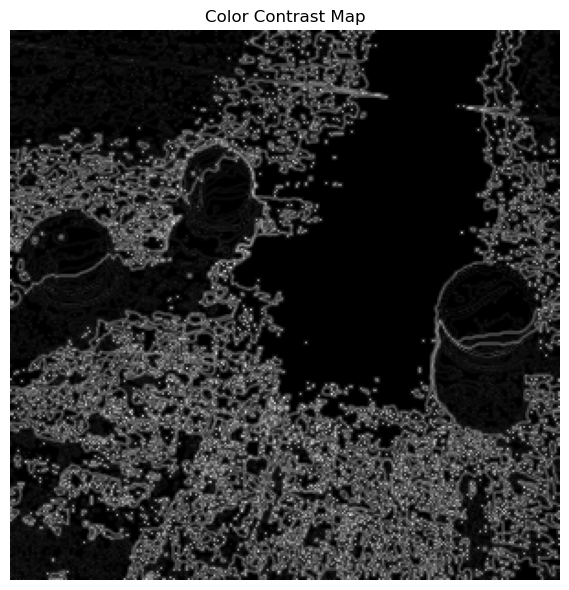

In [58]:
def main(image_path):
    image = Image.open(image_path)
    image_arr = np.array(image, dtype=np.int8)
    quant = quantize_image(image_arr, 16)
    contrast_map = color_contrast_map(quant)
    plt.figure(figsize=(6, 6))
    plt.imshow(contrast_map, cmap='gray')
    plt.title("Color Contrast Map")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

main("/home/ash/Downloads/IMG_300/IMG_5402.jpeg")


Computing largest connected component from combined mask...
Largest component pixels: 3877
Centroid (x, y): (205, 262)


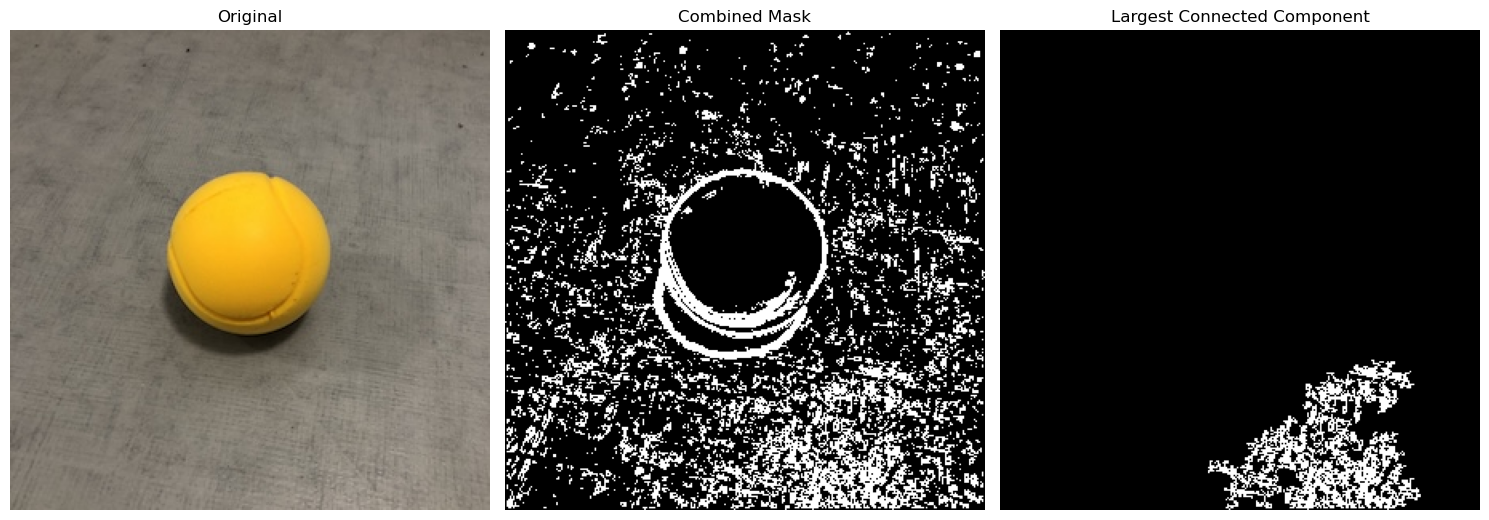

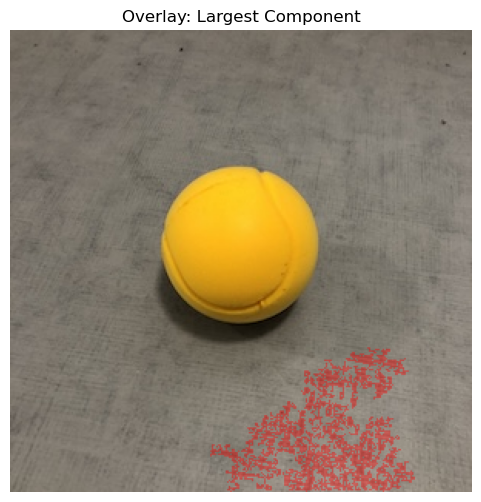

In [59]:

from collections import deque


def flood_fill_label(binary_mask, connectivity=8):
    if binary_mask.dtype != np.bool_:
        mask = binary_mask > 0
    else:
        mask = binary_mask

    h, w = mask.shape
    labels = np.zeros((h, w), dtype=np.int32)
    label = 0

    # neighbor offsets
    if connectivity == 8:
        neigh = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
    else:
        neigh = [(-1,0),(0,-1),(0,1),(1,0)]

    for i in range(h):
        for j in range(w):
            if mask[i, j] and labels[i, j] == 0:
                label += 1
                # BFS
                q = deque()
                q.append((i,j))
                labels[i, j] = label
                while q:
                    y, x = q.popleft()
                    for dy, dx in neigh:
                        ny, nx = y + dy, x + dx
                        if 0 <= ny < h and 0 <= nx < w and mask[ny, nx] and labels[ny, nx] == 0:
                            labels[ny, nx] = label
                            q.append((ny, nx))
    return labels, label


def largest_component_mask(binary_mask, connectivity=8):
    """
    Return a binary mask that contains only the largest connected component.
    """
    labels, num = flood_fill_label(binary_mask, connectivity=connectivity)
    if num == 0:
        return np.zeros_like(binary_mask, dtype=np.uint8)

    # Count pixel per label
    counts = np.bincount(labels.ravel())
    # counts[0] is background, so ignore it
    counts[0] = 0
    largest_label = int(np.argmax(counts))

    out = (labels == largest_label).astype(np.uint8) * 255
    return out


# Example usage with the combined mask produced earlier in the notebook
# (combined_mask should be defined if you ran the combined-edge cell)
try:
    print('Computing largest connected component from combined mask...')
    largest_cc = largest_component_mask(combined_mask, connectivity=8)

    # Optional: compute centroid of largest CC
    ys, xs = np.where(largest_cc > 0)
    if len(xs) > 0:
        centroid = (int(np.mean(xs)), int(np.mean(ys)))
    else:
        centroid = None

    print(f'Largest component pixels: {len(xs)}')
    print(f'Centroid (x, y): {centroid}')

    # Display results side-by-side
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    axes[0].imshow(original_image); axes[0].set_title('Original'); axes[0].axis('off')
    axes[1].imshow(combined_mask, cmap='gray'); axes[1].set_title('Combined Mask'); axes[1].axis('off')
    axes[2].imshow(largest_cc, cmap='gray'); axes[2].set_title('Largest Connected Component'); axes[2].axis('off')
    plt.tight_layout(); plt.show()

    # Overlay the largest component on the original for inspection
    overlay_lcc = apply_mask_overlay(image_rgb.copy(), largest_cc, alpha=0.4)
    plt.figure(figsize=(6,6))
    plt.imshow(overlay_lcc)
    plt.title('Overlay: Largest Component')
    plt.axis('off')
    plt.show()

except NameError:
    print('The variable `combined_mask` is not defined. Run the earlier cells (combined edge map) first.')

# Expose for downstream cells
largest_connected_component = largest_cc if 'largest_cc' in locals() else None


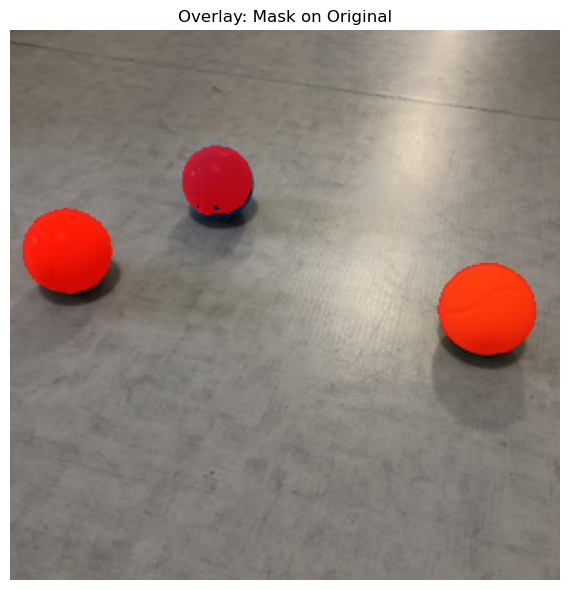

In [13]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load image
image_path = "/home/ash/Downloads/IMG_300/IMG_5402.jpeg"
img = Image.open(image_path)
img_arr = np.array(img, dtype=np.uint8)
h, w, _ = img_arr.shape

# Output binary mask
mask = np.zeros((h, w), dtype=np.uint8)

THRESHOLD = 45  # tune this

for y in range(h):
    for x in range(w):
        b, g, r = img_arr[y, x]

        mx = max(r, g, b)
        mn = min(r, g, b)

        if (mx - mn) > THRESHOLD:
            mask[y, x] = 255

# Overlay mask (red) on the original image with alpha blending
alpha = 0.7
overlay = img_arr.copy().astype(np.float32)
red = np.array([255, 0, 0], dtype=np.float32)

mask_bool = mask > 0  # True where mask is foreground
overlay[mask_bool] = (1 - alpha) * overlay[mask_bool] + alpha * red
overlay = np.clip(overlay, 0, 255).astype(np.uint8)

# Show overlay
plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.title("Overlay: Mask on Original")
plt.axis('off')
plt.tight_layout()
plt.show()